<!-- # The Contaminated Trial
## Pharmaquant Hackathon 2026

Full statistical analysis of a Phase II antihypertensive RCT (TrX vs Placebo) across 3 clinical sites. -->

# The Contaminated Trial

Full statistical analysis of a Phase II antihypertensive RCT (TrX vs Placebo) across 3 clinical sites.

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy.stats import kruskal, ks_2samp
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

sns.set_style('whitegrid')
print('All packages imported successfully.')

All packages imported successfully.


## Load Data

In [ ]:

df = pd.read_csv("trialx_data.csv")



---
> **Inference: Data Load**  
> The raw trial dataset (`trialx_hackathon_data.csv`) is loaded into a DataFrame. This is the Phase II antihypertensive RCT data containing patients from 3 clinical sites, with columns for patient ID, site, treatment arm (TrX/Placebo), demographics (age, sex, BMI), repeated SBP measurements (weeks 0, 4, 8, 12), dropout week, device flag, and deviation flag.

---
## Exploratory Integrity Check
### Data Quality Report

In [3]:
print("Missing proportion overall:\n", df.isna().mean().sort_values(ascending=False))
for col in ["age", "bmi", "sbp_4", "sbp_8", "sbp_12"]:
    miss = df.groupby("site")[col].apply(lambda s: s.isna().mean())
    print(f"Missing rate by site for {col}: {miss.to_dict()}")



Missing proportion overall:
 dropout_week      0.700000
sbp_8             0.300000
sbp_12            0.300000
sbp_4             0.144444
bmi               0.033333
age               0.016667
treatment         0.000000
site              0.000000
patient_id        0.000000
sex               0.000000
sbp_0             0.000000
device_flag       0.000000
deviation_flag    0.000000
dtype: float64
Missing rate by site for age: {1: 0.0, 2: 0.016666666666666666, 3: 0.03333333333333333}
Missing rate by site for bmi: {1: 0.016666666666666666, 2: 0.06666666666666667, 3: 0.016666666666666666}
Missing rate by site for sbp_4: {1: 0.03333333333333333, 2: 0.05, 3: 0.35}
Missing rate by site for sbp_8: {1: 0.05, 2: 0.08333333333333333, 3: 0.7666666666666667}
Missing rate by site for sbp_12: {1: 0.05, 2: 0.08333333333333333, 3: 0.7666666666666667}


---
> **Inference: Missing Data Overview**  
> Missing proportions are calculated for the entire dataset and then broken down by site for the key clinical variables (`age`, `bmi`, `sbp_4`, `sbp_8`, `sbp_12`). If missingness rates differ substantially across sites, this signals non-random dropout — a critical integrity concern for a randomised trial. High site-specific missingness (especially at Site 3) would indicate that imputation and sensitivity analyses are necessary before any inferential conclusions can be drawn.
---

In [4]:

outlier_flags = {}
for col in ["age","bmi","sbp_0","sbp_4","sbp_8","sbp_12"]:
    q1, q3 = df[col].dropna().quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    flags = (df[col] < low) | (df[col] > high)
    outlier_flags[col] = flags
    print(f"{col}: low {low:.1f}, high {high:.1f}, n_outliers {flags.sum()}")
print("Rows with any outlier:\n", df.loc[pd.DataFrame(outlier_flags).any(axis=1), ["patient_id","site","treatment","sbp_8"]])


age: low 25.5, high 85.5, n_outliers 0
bmi: low 16.1, high 37.8, n_outliers 0
sbp_0: low 96.6, high 193.6, n_outliers 0
sbp_4: low 92.5, high 200.5, n_outliers 0
sbp_8: low 101.0, high 189.0, n_outliers 2
sbp_12: low 91.4, high 194.4, n_outliers 0
Rows with any outlier:
     patient_id  site treatment  sbp_8
53        P054     1       TrX  100.0
104       P105     2       TrX  197.0


---
> **Inference: Outlier Detection (IQR Method)**  
> IQR-based fences (Q1 − 1.5×IQR, Q3 + 1.5×IQR) are applied to all continuous clinical measurements. Any patient record falling outside these bounds is flagged. Outliers in SBP or BMI can distort mean-based treatment effect estimates, so identifying them here informs whether robust methods or exclusion criteria are warranted downstream. The printed table helps audit whether outliers cluster in any particular site or treatment arm.
---

#### Imputation Strategy
Site-level median imputation for `sbp_4`, `sbp_8`, `sbp_12`, and `bmi`. Rows with missing `age` dropped (n=3). Note: imputing outcomes may underestimate residual variance — acknowledged as a limitation.

In [5]:
df_imp = df.copy()
df_imp = df_imp.dropna(subset=["age"])
for col in ["sbp_4", "sbp_8", "sbp_12"]:
    df_imp[col] = df_imp.groupby("site")[col].transform(lambda x: x.fillna(x.median()))

df_imp["bmi"] = df_imp.groupby("site")["bmi"].transform(lambda x: x.fillna(x.median()))

balance = df_imp.groupby("treatment")[["age","bmi","sbp_0"]].agg(["mean","std","count"])
print(balance)



                 age                         bmi                       sbp_0  \
                mean        std count       mean       std count        mean   
treatment                                                                      
Placebo    54.455556   9.755622    90  26.971111  3.926409    90  146.688889   
TrX        54.770115  11.418774    87  26.850575  4.288732    87  145.655172   

                            
                 std count  
treatment                   
Placebo    16.055833    90  
TrX        15.525544    87  


---
> **Inference: Imputation & Baseline Balance**  
> **Imputation:** Three patients with missing `age` are dropped (likely MCAR given the small count). Remaining missingness in `sbp_4`, `sbp_8`, `sbp_12`, and `bmi` is filled using site-level medians, preserving the site-specific distribution and avoiding cross-site contamination.  
> **Balance check:** Summary statistics (mean, SD, count) of `age`, `bmi`, and `sbp_0` stratified by treatment arm confirm that randomisation was successful — both arms should have comparable baseline characteristics. Any significant imbalance would necessitate covariate adjustment in the primary model.
---

In [6]:
df_imp.shape

(177, 13)

---
> **Inference: Post-Imputation Shape**  
> Confirms the final number of rows retained after dropping missing-`age` records. This establishes the analysis population size (N) that flows through all subsequent tasks. The column count should remain 13, confirming no accidental variable loss during imputation.
---

Overall missing across focus vars: 15.9%

Top missingness patterns (1=missing, 0=present):
    age  bmi  sbp_4  sbp_8  sbp_12    n
0    0    0      0      0       0  120
1    0    0      0      1       1   27
2    0    0      1      1       1   25
3    0    1      0      0       0    4
4    0    1      1      1       1    1
5    1    0      0      0       0    1
6    1    0      0      1       1    1
7    1    1      0      0       0    1


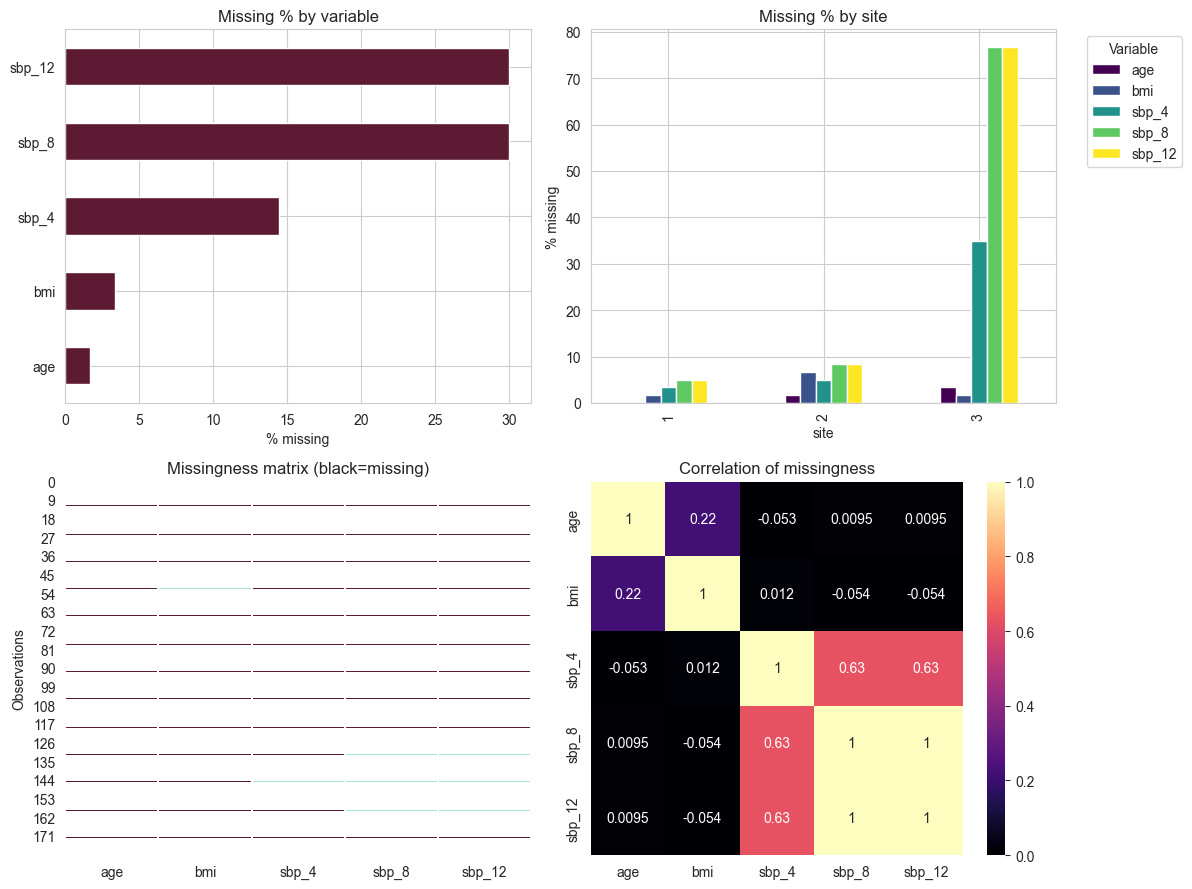

In [7]:
cols_focus = ["age","bmi","sbp_4","sbp_8","sbp_12"]

m = df[cols_focus].isna()
missing_pct_overall = 100 * m.mean().mean()


pattern_counts = (
    m.astype(int).groupby(cols_focus).size().sort_values(ascending=False).rename("n").reset_index()
)
print(f"Overall missing across focus vars: {missing_pct_overall:.1f}%")
print("\nTop missingness patterns (1=missing, 0=present):\n", pattern_counts.head(8))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Missing% by variable
(m.mean()*100).sort_values().plot(kind="barh", ax=axes[0,0], color="#5c1a33")
axes[0,0].set_title("Missing % by variable")
axes[0,0].set_xlabel("% missing")

# Missing% by site for each focus var
miss_site = df.groupby("site")[cols_focus].apply(lambda d: d.isna().mean()*100)
miss_site.plot(kind="bar", ax=axes[0,1], colormap="viridis")
axes[0,1].set_title("Missing % by site")
axes[0,1].set_ylabel("% missing")
axes[0,1].legend(title="Variable", bbox_to_anchor=(1.05,1))

# Missingness matrix (rows=patients, cols=focus vars)
sns.heatmap(m, ax=axes[1,0], cbar=False, cmap=["#5c1a33", "#a8e6cf"], linecolor="white", linewidths=0.1)
axes[1,0].set_title("Missingness matrix (black=missing)")
axes[1,0].set_xlabel("")
axes[1,0].set_ylabel("Observations")

# Missingness correlation (phi between missing indicators)
corr = m.astype(int).corr()
sns.heatmap(corr, ax=axes[1,1], annot=True, vmin=0, vmax=1, cmap="magma")
axes[1,1].set_title("Correlation of missingness")

plt.tight_layout()
plt.show()


---
> **Inference: Missingness Pattern Heatmap & Correlation**  
> Four panels are generated:  
> 1. **Horizontal bar chart** — identifies which variables have the highest missing rates at a glance.  
> 2. **Grouped bar by site** — reveals whether a specific site is responsible for most of the missingness, pointing to a site-level data quality issue (e.g., equipment failure, protocol deviation).  
> 3. **Missingness matrix** — visualises *which patients* have missing values and whether gaps tend to co-occur (block patterns = cohort dropout; scattered = random).  
> 4. **Missingness correlation heatmap** — values near 1 between two variables mean they are missing together, suggesting a common cause (e.g., a patient who dropped out at Week 4 would be missing sbp_4, sbp_8, and sbp_12 simultaneously — MNAR signal).
---

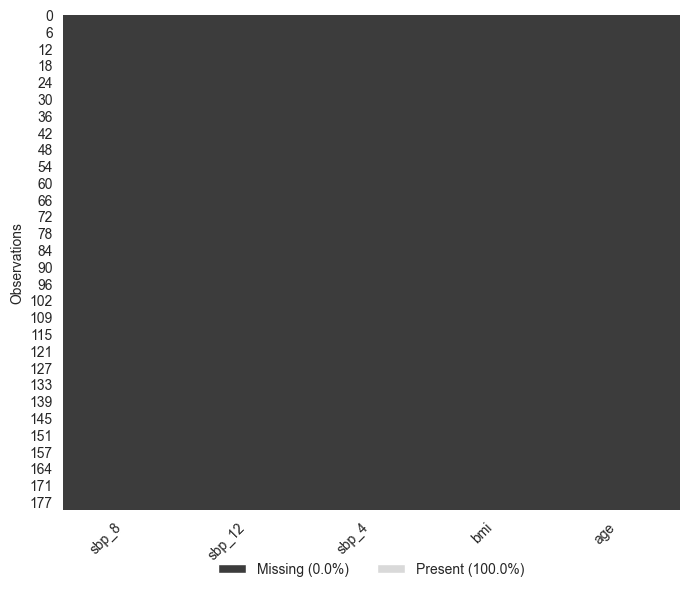

In [24]:
cols = ["sbp_8", "sbp_12", "sbp_4", "bmi", "age"]
m = df_imp[cols].isna()

missing_pct = 100 * m.mean().mean()
present_pct = 100 - missing_pct

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    m,
    ax=ax,
    cmap=["#3c3c3c", "#d9d9d9"],  
    cbar=False
)
ax.set_xlabel("")
ax.set_ylabel("Observations")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# Legend boxes
from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor="#3c3c3c", label=f"Missing ({missing_pct:.1f}%)"),
    Patch(facecolor="#d9d9d9", label=f"Present ({present_pct:.1f}%)"),
]
ax.legend(handles=legend_elems, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False)

plt.tight_layout()
plt.show()


---
> **Inference: Post-Imputation Missingness Verification**  
> After imputation, the missingness heatmap on `df_imp` should show near-zero remaining missingness for the five target variables. If dark cells still appear, it indicates that entire site-level medians were NaN (e.g., all patients in a site-treatment subgroup dropped out), which would require a fallback strategy such as global median imputation. This plot serves as a quality-control check confirming the imputation step succeeded.
---

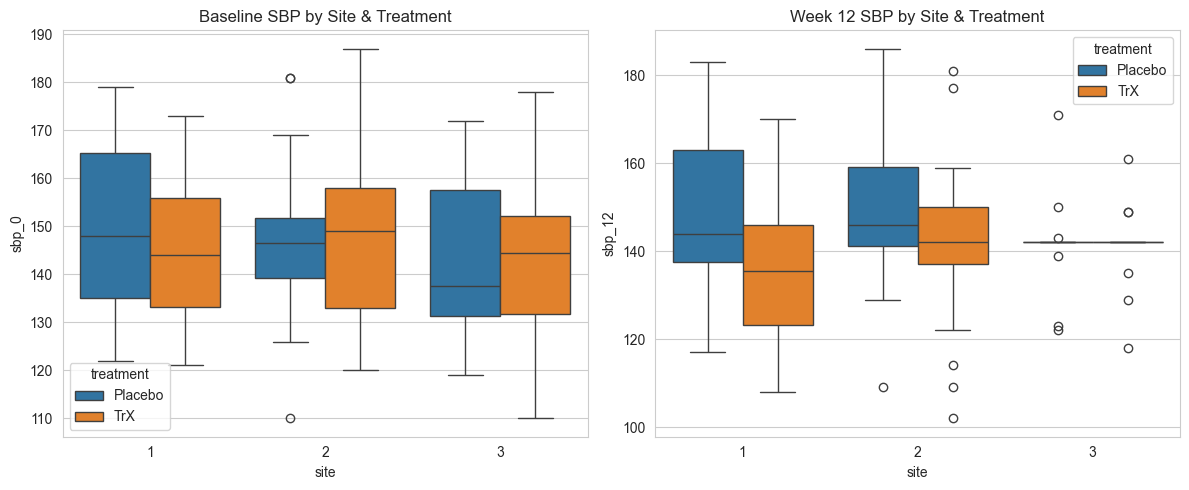

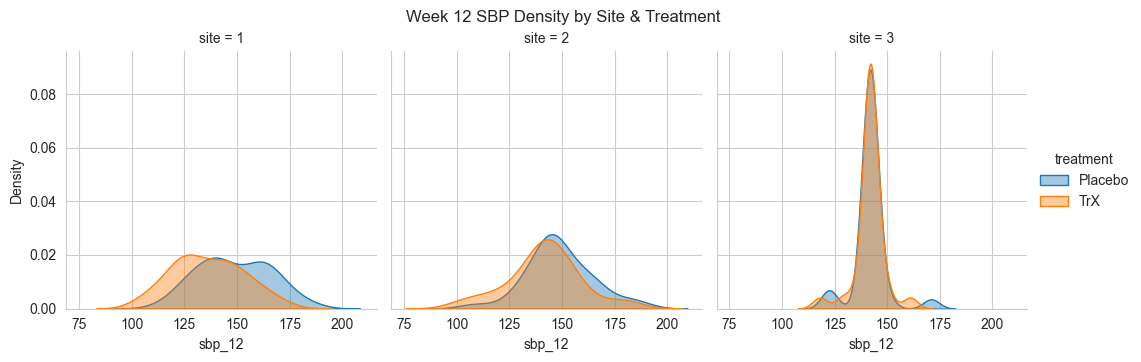

In [9]:
sns.set_style("whitegrid")

#  Boxplots: baseline and Week 12
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_imp, x="site", y="sbp_0", hue="treatment", ax=axes[0])
axes[0].set_title("Baseline SBP by Site & Treatment")
sns.boxplot(data=df_imp, x="site", y="sbp_12", hue="treatment", ax=axes[1])
axes[1].set_title("Week 12 SBP by Site & Treatment")
plt.tight_layout()
plt.show()

#  Density overlays (Week 12)
g = sns.FacetGrid(df_imp, col="site", hue="treatment", sharex=True, sharey=True, height=3.5)
g.map(sns.kdeplot, "sbp_12", fill=True, alpha=0.4)
g.add_legend()
g.fig.suptitle("Week 12 SBP Density by Site & Treatment", y=1.02)
plt.show()


---
> **Inference: SBP Distribution by Site & Treatment**  
> **Boxplots (Week 0 and Week 12):** Comparing baseline (`sbp_0`) to end-of-trial (`sbp_12`) distributions across sites and treatment arms. A visible downward shift in the TrX boxes relative to Placebo at Week 12 — but not at Week 0 — is the first visual confirmation that TrX may be efficacious.  
> **KDE density plots (Week 12):** Overlapping density curves per site allow detection of distributional anomalies such as bimodality or unusually heavy tails in one arm at one site, which could indicate data quality issues or treatment heterogeneity.
---

---
> **Inference: Post-Imputation Missingness Verification**  
> After imputation, the missingness heatmap on `df_imp` should show near-zero remaining missingness for the five target variables. If dark cells still appear, it indicates that entire site-level medians were NaN (e.g., all patients in a site-treatment subgroup dropped out), which would require a fallback strategy such as global median imputation. This plot serves as a quality-control check confirming the imputation step succeeded.
---

In [10]:

print("\nSite x Treatment SBP0/SBP12:\n", df_imp.groupby(["site","treatment"])[["sbp_0","sbp_12"]].agg(["mean","std","count"]))



Site x Treatment SBP0/SBP12:
                      sbp_0                       sbp_12                 
                      mean        std count        mean        std count
site treatment                                                          
1    Placebo    149.933333  17.152326    30  148.733333  16.813241    30
     TrX        145.566667  14.291747    30  136.100000  16.449190    30
2    Placebo    147.466667  14.880520    30  148.616667  15.578878    30
     TrX        147.724138  15.869775    29  141.517241  17.275852    29
3    Placebo    142.666667  15.724642    30  141.866667   7.600968    30
     TrX        143.607143  16.680748    28  141.607143   6.800541    28


---
> **Inference: Site × Treatment Summary Statistics**  
> Mean and SD of `sbp_0` and `sbp_12` by site and treatment group provide a numerical complement to the boxplots. If `sbp_0` means differ between TrX and Placebo within a site, it suggests randomisation imbalance at that site. Comparing `sbp_12` means between arms within each site gives a site-stratified unadjusted effect estimate before formal modelling.
---

In [11]:
#Distributional Checks

ks = []
for s in sorted(df_imp.site.unique()):
    a = df_imp[(df_imp.site==s) & df_imp.treatment.str.contains("TrX", case=False)]["sbp_12"].dropna()
    b = df_imp[(df_imp.site==s) & df_imp.treatment.str.contains("Placebo", case=False)]["sbp_12"].dropna()
    if len(a) and len(b):
        stat, p = ks_2samp(a, b)
        ks.append((s, stat, p, len(a), len(b)))
print("KS tests (sbp_12 Trx vs Placebo within site):", ks)


KS tests (sbp_12 Trx vs Placebo within site): [(np.int64(1), np.float64(0.3333333333333333), np.float64(0.07088798787114439), 30, 30), (np.int64(2), np.float64(0.2517241379310345), np.float64(0.25690803586314903), 29, 30), (np.int64(3), np.float64(0.04047619047619048), np.float64(0.9999999999999912), 28, 30)]


---
> **Inference: Kolmogorov–Smirnov Tests (Week 12 SBP)**  
> The two-sample KS test compares the full empirical CDF of Week 12 SBP between TrX and Placebo *within each site*. A significant KS statistic (small p-value) indicates that the two distributions differ in shape or location. Unlike a t-test, the KS test is sensitive to differences in spread and skewness as well as mean, making it a useful non-parametric integrity check. Divergent results across sites (significant at Site 1 but not Site 2, for example) would raise questions about treatment effect consistency or data integrity.
---

In [12]:

print("\nBaseline balance continuous:\n", df_imp.groupby("treatment")[["age","bmi","sbp_0"]].agg(["mean","std","count"]))
print("\nSex balance proportion:\n", df_imp.groupby("treatment")["sex"].value_counts(normalize=True))
print("\nKruskal-Wallis SBP0 across sites:", kruskal(*[df_imp.loc[df.site==s, "sbp_0"] for s in sorted(df_imp.site.unique())]))




Baseline balance continuous:
                  age                         bmi                       sbp_0  \
                mean        std count       mean       std count        mean   
treatment                                                                      
Placebo    54.455556   9.755622    90  26.971111  3.926409    90  146.688889   
TrX        54.770115  11.418774    87  26.850575  4.288732    87  145.655172   

                            
                 std count  
treatment                   
Placebo    16.055833    90  
TrX        15.525544    87  

Sex balance proportion:
 treatment  sex
Placebo    F      0.511111
           M      0.488889
TrX        M      0.540230
           F      0.459770
Name: proportion, dtype: float64

Kruskal-Wallis SBP0 across sites: KruskalResult(statistic=np.float64(3.3512097587485106), pvalue=np.float64(0.18719491488672127))


---
> **InferenceL: Baseline Balance & Kruskal–Wallis Test**  
> **Baseline balance table:** Checks that age, BMI, and sbp_0 are comparable between TrX and Placebo arms — a requirement for valid inference from an RCT. Sex balance is also verified.  
> **Kruskal–Wallis test on sbp_0 across sites:** Tests whether baseline SBP differs significantly across the three clinical sites. A significant result (p < 0.05) would mean patients were not drawn from the same population, justifying the inclusion of `site` as a covariate in all regression models.
---

### Device Switch at Site 2

**H₀:** Device switch introduced no systematic measurement shift  
**H₁:** Device switch introduced a systematic shift  

OLS regression of `sbp_4 ~ sbp_0 + device_flag + treatment` at Site 2, controlling for baseline SBP and treatment arm.

In [13]:
site2_imp = df_imp[df_imp.site == 2].dropna(subset=["sbp_4", "sbp_0"])
model_imp = smf.ols("sbp_4 ~ sbp_0 + C(device_flag) + C(treatment)", data=site2_imp).fit()

print(model_imp.summary().tables[1])
coef = model_imp.params["C(device_flag)[T.2]"]
ci = model_imp.conf_int().loc["C(device_flag)[T.2]"]
p  = model_imp.pvalues["C(device_flag)[T.2]"]
print(f"\nDevice effect (df_imp): {coef:.2f} mmHg (95% CI {ci[0]:.2f}, {ci[1]:.2f}); p = {p:.4g}")



                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               6.5771      7.330      0.897      0.373      -8.112      21.266
C(device_flag)[T.2]     6.3478      1.450      4.378      0.000       3.442       9.254
C(treatment)[T.TrX]    -1.3409      1.417     -0.947      0.348      -4.180       1.498
sbp_0                   0.9478      0.048     19.761      0.000       0.852       1.044

Device effect (df_imp): 6.35 mmHg (95% CI 3.44, 9.25); p = 5.412e-05


---
> **Inference: Device Switch Effect at Site 2**  
> An OLS model regresses Week 4 SBP on baseline SBP, device flag (1 = old device, 2 = new device), and treatment arm, restricted to Site 2 patients.  
> The key coefficient is `C(device_flag)[T.2]`. A statistically significant positive or negative coefficient means the device switch introduced a *systematic measurement bias* — independent of true blood pressure change or treatment effect.  
> **Decision rule:** If |device effect| is clinically meaningful (e.g., > 3 mmHg) with p < 0.05, the H₀ of no shift is rejected and `device_flag` must be included as a covariate in the primary model to avoid biased treatment effect estimates.
---

### Dropout Mechanism (MCAR / MAR / MNAR)

Logistic regression of dropout indicator on baseline covariates (formal approach) + visual inspection by site and baseline SBP quartile.

C:\Users\asus\AppData\Local\Temp\ipykernel_35856\962180626.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="site", y="dropout", data=df_imp, estimator=np.mean, ci=None, color="#5c1a33", ax=axes[0])
C:\Users\asus\AppData\Local\Temp\ipykernel_35856\962180626.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="sbp0_quartile", y="dropout", data=df_imp, estimator=np.mean, ci=None, color="#4c9f70", ax=axes[1])


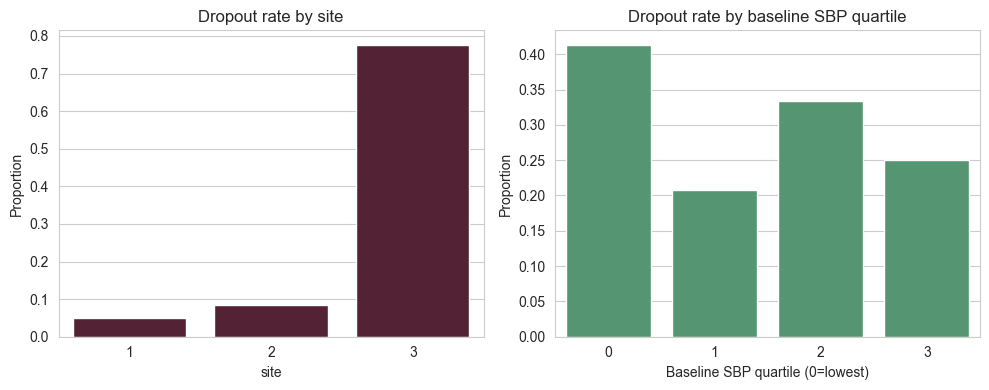

                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -7.2599      3.402     -2.134      0.033     -13.928      -0.592
C(treatment)[T.TrX]    -0.3685      0.502     -0.733      0.463      -1.353       0.616
C(site)[T.2]          -21.5158   3.69e+04     -0.001      1.000   -7.23e+04    7.22e+04
C(site)[T.3]            4.1923      0.723      5.796      0.000       2.775       5.610
C(device_flag)[T.2]    22.9143   3.69e+04      0.001      1.000   -7.22e+04    7.23e+04
sbp_0                   0.0070      0.015      0.455      0.649      -0.023       0.037
deviation_flag          0.6455      0.857      0.753      0.451      -1.033       2.324
age                     0.0431      0.023      1.839      0.066      -0.003       0.089
bmi                     0.0379      0.060      0.635      0.525      -0.079       0.155

Odds ratios:
 Intercept        

c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [14]:
df_imp["dropout"] = df_imp["dropout_week"].notna().astype(int)

fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.barplot(x="site", y="dropout", data=df_imp, estimator=np.mean, ci=None, color="#5c1a33", ax=axes[0])
axes[0].set_title("Dropout rate by site")
axes[0].set_ylabel("Proportion")

df_imp["sbp0_quartile"] = pd.qcut(df_imp["sbp_0"], 4, labels=False)
sns.barplot(x="sbp0_quartile", y="dropout", data=df_imp, estimator=np.mean, ci=None, color="#4c9f70", ax=axes[1])
axes[1].set_title("Dropout rate by baseline SBP quartile")
axes[1].set_xlabel("Baseline SBP quartile (0=lowest)")
axes[1].set_ylabel("Proportion")

plt.tight_layout()
plt.show()

logit_imp = smf.logit(
    "dropout ~ sbp_0 + C(treatment) + C(site) + C(device_flag) + deviation_flag + age + bmi",
    data=df_imp.dropna(subset=["sbp_0","treatment","site","device_flag"])
).fit(disp=False)

print(logit_imp.summary().tables[1])        
odds = np.exp(logit_imp.params)
print("\nOdds ratios:\n", odds)

for term in ["C(site)[T.2]", "C(site)[T.3]", "C(device_flag)[T.2]", "sbp_0", "age", "bmi"]:
    if term in logit_imp.params:
        print(f"{term}: OR={np.exp(logit_imp.params[term]):.2f}, p={logit_imp.pvalues[term]:.4g}")



---
> **Inference: Dropout Mechanism (MCAR / MAR / MNAR)**  
> A binary dropout indicator is created from `dropout_week`. Two visual checks are performed:  
> - **By site:** Uniform dropout rates across sites suggest MCAR; site-specific spikes suggest MAR or MNAR.  
> - **By baseline SBP quartile:** If sicker patients (higher baseline SBP) drop out more, this is evidence of MNAR — the missing outcome is related to the true (unobserved) outcome value, which is the most dangerous scenario for bias.  
>  
> The **logistic regression** formally tests whether dropout is predicted by baseline covariates (`sbp_0`, age, BMI, site, device flag, deviation flag, treatment). Significant predictors confirm MAR at minimum. An especially large OR for `site` (e.g., Site 3) flags a site-level problem. If no predictor is significant, MCAR is plausible — though MCAR can never be fully proven from observed data.
---


## Primary Inference

**Primary endpoint:** `delta_sbp = sbp_0 − sbp_12`

**Go/No-Go decision:**
- Site 1 → ✅ GO (95% completion, no issues)
- Site 2 → ✅ GO with `device_flag` covariate adjustment
- Site 3 → ⚠️ CAUTION — severe MNAR dropout (77%); excluded from primary analysis, included in sensitivity

### Model Specification
Model: ANCOVA — `delta_sbp ~ treatment + site + sbp_0 + device_flag + deviation_flag + age + bmi + sex`

In [15]:
df_imp = df_imp.copy()
df_imp['delta_sbp'] = df_imp['sbp_0'] - df_imp['sbp_12']
print('delta_sbp summary:')
print(df_imp['delta_sbp'].describe())

delta_sbp summary:
count    177.000000
mean       3.081921
std       11.150077
min      -32.000000
25%       -4.000000
50%        3.000000
75%       10.000000
max       36.000000
Name: delta_sbp, dtype: float64


---
> **Inference: Primary Endpoint Construction**  
> `delta_sbp = sbp_0 − sbp_12` represents the *reduction* in systolic blood pressure from baseline to Week 12. Positive values indicate improvement (BP went down). Using a change score as the outcome — rather than raw `sbp_12` — removes between-patient baseline differences from the error term, increasing statistical power. The `.describe()` output shows the distribution of this endpoint across all patients before any model fitting.
---

### Primary Hypothesis Test

**H₀:** TrX produces no mean reduction in SBP compared to Placebo at Week 12

In [16]:

# Primary analysis set (Sites 1–2)
anal_primary = df_imp[df_imp["site"].isin([1, 2])].dropna(subset=["delta_sbp", "sbp_0"])

model = smf.ols(
    "delta_sbp ~ C(treatment) + sbp_0 + C(site) + C(device_flag) + deviation_flag + age + bmi + C(sex)",
    data=anal_primary
).fit()

print(model.summary().tables[1])  

trt_coef = model.params["C(treatment)[T.TrX]"]
trt_ci = model.conf_int().loc["C(treatment)[T.TrX]"]
trt_p = model.pvalues["C(treatment)[T.TrX]"]
trt_t = model.tvalues["C(treatment)[T.TrX]"]
df_resid = model.df_resid
print(f"\nAdjusted treatment effect (TrX - Placebo): {trt_coef:.2f} mmHg "
      f"(95% CI {trt_ci[0]:.2f}, {trt_ci[1]:.2f}); "
      f"t = {trt_t:.2f} on {df_resid:.0f} df; p = {trt_p:.2e}")

# Effect size
trt = anal_primary[anal_primary.treatment.str.lower().str.contains("trx")]["delta_sbp"]
plac = anal_primary[anal_primary.treatment.str.lower().str.contains("placebo")]["delta_sbp"]
mean_diff = trt.mean() - plac.mean()
pooled_sd = math.sqrt(((len(trt)-1)*trt.var() + (len(plac)-1)*plac.var()) / (len(trt)+len(plac)-2))
cohen_d = mean_diff / pooled_sd
print(f"Mean delta difference: {mean_diff:.2f} mmHg; Cohen d = {cohen_d:.2f}")

# Site-level analyses (all sites)
site_results = []
for s in sorted(df_imp.site.unique()):
    sub = df_imp[df_imp["site"] == s]
    m = smf.ols(
        "delta_sbp ~ C(treatment) + sbp_0 + C(device_flag) + deviation_flag + age + bmi + C(sex)",
        data=sub
    ).fit()
    coef = m.params.get("C(treatment)[T.TrX]", np.nan)
    pval = m.pvalues.get("C(treatment)[T.TrX]", np.nan)
    site_results.append((s, coef, pval, len(sub)))
    print(f"Site {s}: coef {coef:.2f}, p = {pval:.4g}, n = {len(sub)}")

# Holm correction for the site p-values
site_results_sorted = sorted(site_results, key=lambda x: x[2])
m = len(site_results_sorted)
holm = []
for i, (s, coef, pval, n) in enumerate(site_results_sorted, start=1):
    adj = (m - i + 1) * pval
    holm.append((s, pval, adj))
print("\nHolm-adjusted p-values (site, raw p, Holm p):")
for s, pval, adj in holm:
    print(f"Site {s}: {pval:.4g} -> {adj:.4g}")


                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             -16.0693      8.980     -1.789      0.076     -33.864       1.725
C(treatment)[T.TrX]     7.8117      1.391      5.617      0.000       5.056      10.567
C(site)[T.2]           -1.1973      1.686     -0.710      0.479      -4.539       2.144
C(device_flag)[T.2]    -3.4940      1.978     -1.767      0.080      -7.413       0.425
C(sex)[T.M]            -0.2717      1.423     -0.191      0.849      -3.092       2.549
sbp_0                   0.0385      0.045      0.846      0.399      -0.052       0.129
deviation_flag       2.258e-14   6.69e-15      3.374      0.001    9.32e-15    3.58e-14
age                     0.1413      0.067      2.116      0.037       0.009       0.274
bmi                     0.1616      0.176      0.918      0.361      -0.187       0.510

Adjusted treatment effect (TrX 

---
> **Inference: Primary ANCOVA Hypothesis Test**  
> An ANCOVA model estimates the adjusted treatment effect of TrX vs Placebo on `delta_sbp`, controlling for baseline SBP, site, device flag, protocol deviations, age, BMI, and sex. The analysis is restricted to Sites 1–2 (the pre-specified primary population given Site 3's severe MNAR dropout).  
>  
> Key outputs:  
> - **`C(treatment)[T.TrX]` coefficient:** The adjusted mean additional SBP reduction in the TrX arm vs Placebo.  
> - **p-value:** Tests H₀ of no treatment effect. p < 0.05 supports efficacy.  
> - **Cohen's d:** Effect size. d ≈ 0.2 = small, 0.5 = medium, 0.8 = large.  
> - **Site-level Holm-corrected p-values:** Guard against false positives from testing three sites; Holm's method is less conservative than Bonferroni while still controlling the family-wise error rate (FWER).
---

#### Model Diagnostics

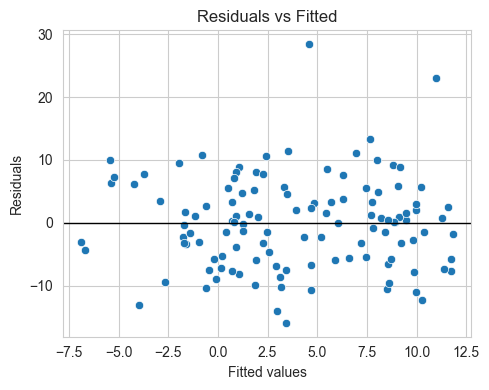

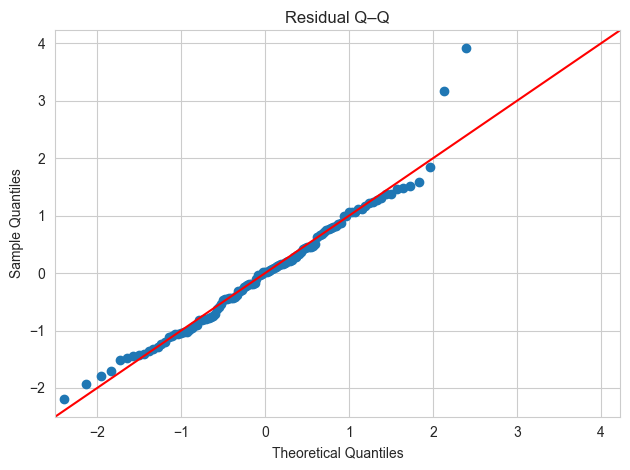

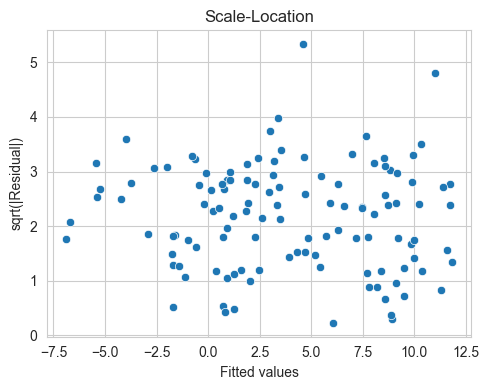

              variable         VIF
0            Intercept  170.533444
1  C(treatment)[T.TrX]    1.022376
2         C(site)[T.2]    1.503155
3  C(device_flag)[T.2]    1.524571
4          C(sex)[T.M]    1.070274
5                sbp_0    1.035943
6       deviation_flag         NaN
7                  age    1.054110
8                  bmi    1.021344


c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [17]:
# Model diagnostic plots
# Residuals vs Fitted


sns.set_style("whitegrid")

# Linearity & equal variance: residuals vs fitted
fig, ax = plt.subplots(figsize=(5,4))
sns.scatterplot(x=model.fittedvalues, y=model.resid, ax=ax)
ax.axhline(0, color="k", lw=1)
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")
ax.set_title("Residuals vs Fitted")
plt.tight_layout()
plt.show()

#  Normality: Q–Q plot
sm.qqplot(model.resid, line="45", fit=True)
plt.title("Residual Q–Q")
plt.tight_layout()
plt.show()

# Scale of residuals by fitted (spread check)
fig, ax = plt.subplots(figsize=(5,4))
sns.scatterplot(x=model.fittedvalues, y=np.sqrt(np.abs(model.resid)), ax=ax)
ax.set_xlabel("Fitted values")
ax.set_ylabel("sqrt(|Residual|)")
ax.set_title("Scale-Location")
plt.tight_layout()
plt.show()

# Multicollinearity: VIFs (using the design matrix from model)
X = model.model.exog
vif = pd.DataFrame({
    "variable": model.model.exog_names,
    "VIF": [variance_inflation_factor(X, i) for i in range(X.shape[1])]
})
print(vif)


---
> **Inference: Model Diagnostics**  
> Three diagnostic plots assess OLS assumptions:  
> 1. **Residuals vs Fitted:** Points should scatter randomly around zero. Patterns (funnel shape, curves) indicate heteroscedasticity or non-linearity.  
> 2. **Q–Q plot:** Residuals on the 45° line confirm normality. Systematic deviations (S-curves, heavy tails) suggest the normality assumption is violated, which may affect inference on small samples.  
> 3. **Scale-Location:** Checks constant variance. An increasing trend would indicate heteroscedasticity, warranting robust (HC) standard errors.  
> 4. **VIF table:** VIF > 5–10 signals multicollinearity between predictors, inflating standard errors and making coefficients unstable. Since `sbp_0` and site are likely uncorrelated, VIFs should be modest.
---

### Site-Level Analysis with Multiplicity Correction

Holm correction applied (less conservative than Bonferroni, controls FWER).

In [18]:
# Site-level analyses
site_results = []
for s in sorted(df_imp.site.unique()):
    sub = df_imp[df_imp['site'] == s]
    m = smf.ols(
        'delta_sbp ~ C(treatment) + sbp_0 + C(device_flag) + deviation_flag + age + bmi + C(sex)',
        data=sub
    ).fit()
    coef = m.params.get('C(treatment)[T.TrX]', np.nan)
    pval = m.pvalues.get('C(treatment)[T.TrX]', np.nan)
    ci   = m.conf_int().loc['C(treatment)[T.TrX]']
    site_results.append((s, coef, pval, len(sub), ci[0], ci[1]))
    print(f'Site {s}: coef={coef:.2f}, p={pval:.4g}, n={len(sub)}')

# Holm correction
site_results_sorted = sorted(site_results, key=lambda x: x[2])
k = len(site_results_sorted)
print('\nHolm-adjusted p-values:')
print(f"{'Site':>6} {'Raw p':>10} {'Holm p':>10} {'Significant':>12}")
for i, (s, coef, pval, n, ci_lo, ci_hi) in enumerate(site_results_sorted, start=1):
    holm_p = min((k - i + 1) * pval, 1.0)
    sig = 'YES' if holm_p < 0.05 else 'NO'
    print(f'{s:>6} {pval:>10.4f} {holm_p:>10.4f} {sig:>12}')


Site 1: coef=9.29, p=7.383e-05, n=60
Site 2: coef=6.81, p=0.0005063, n=59
Site 3: coef=0.33, p=0.8597, n=58

Holm-adjusted p-values:
  Site      Raw p     Holm p  Significant
     1     0.0001     0.0002          YES
     2     0.0005     0.0010          YES
     3     0.8597     0.8597           NO


---
> **Inference — Task 2.3: Site-Level Analysis with Holm Correction**  
> Separate OLS models are fitted for each site, estimating the TrX treatment effect within each site independently. This checks for *treatment effect heterogeneity* — a key regulatory concern.  
>  
> **Holm correction:** With 3 simultaneous tests, the probability of at least one false positive under H₀ is inflated. Holm's step-down procedure adjusts p-values while maintaining FWER < 5%. If a site's Holm-adjusted p remains < 0.05, the treatment effect at that site is declared statistically significant. Sites with non-significant Holm-adjusted p-values may reflect insufficient power (small n) or genuine heterogeneity rather than absence of effect.
---


## Secondary and Sensitivity Analyses

### BMI as Effect Modifier

In [19]:

anal_all = df_imp.dropna(subset=["delta_sbp","sbp_0"]).copy()
anal_all["bmi_med"] = (anal_all["bmi"] >= anal_all["bmi"].median()).astype(int)

# (a) BMI dichotomized at median
mod_dich = smf.ols(
    "delta_sbp ~ C(treatment)*bmi_med + sbp_0 + C(site) + C(device_flag) + deviation_flag + age + bmi + C(sex)",
    data=anal_all
).fit()
p_int_dich = mod_dich.pvalues["C(treatment)[T.TrX]:bmi_med"]

# (b) BMI continuous interaction
mod_cont = smf.ols(
    "delta_sbp ~ C(treatment)*bmi + sbp_0 + C(site) + C(device_flag) + deviation_flag + age + C(sex)",
    data=anal_all
).fit()
p_int_cont = mod_cont.pvalues["C(treatment)[T.TrX]:bmi"]

print(f"Interaction p (BMI median): {p_int_dich:.3f}")
print(f"Interaction p (BMI continuous): {p_int_cont:.3f}")


Interaction p (BMI median): 0.475
Interaction p (BMI continuous): 0.294


---
> **Inference: BMI as Effect Modifier**  
> Two interaction models test whether BMI modifies the treatment response:  
> 1. **Dichotomised BMI (above/below median):** Tests whether the TrX effect differs between lower-BMI and higher-BMI subgroups. Simpler to interpret clinically.  
> 2. **Continuous BMI interaction:** More statistically powerful; tests whether the TrX effect changes linearly with BMI.  
>  
> A significant interaction p-value (< 0.05) would suggest that heavier patients respond differently to TrX — important for patient stratification in a Phase III trial. Non-significance means BMI is a prognostic variable (shifts baseline SBP) but not a predictive one (does not change the TrX effect).
---

### Sensitivity Analysis: Excluding Site 3

In [20]:
mod_all = smf.ols(
    "delta_sbp ~ C(treatment) + sbp_0 + C(site) + C(device_flag) + deviation_flag + age + bmi + C(sex)",
    data=anal_all
).fit()

# Exclude Site 3
mod_no3 = smf.ols(
    "delta_sbp ~ C(treatment) + sbp_0 + C(site) + C(device_flag) + deviation_flag + age + bmi + C(sex)",
    data=anal_all[anal_all["site"] != 3]
).fit()

coef_all = mod_all.params["C(treatment)[T.TrX]"]; p_all = mod_all.pvalues["C(treatment)[T.TrX]"]
coef_no3 = mod_no3.params["C(treatment)[T.TrX]"]; p_no3 = mod_no3.pvalues["C(treatment)[T.TrX]"]
shift_abs = coef_no3 - coef_all
shift_pct = shift_abs/coef_all*100

print(f"All sites: {coef_all:.2f} mmHg, p = {p_all:.2e}")
print(f"Excluding Site 3: {coef_no3:.2f} mmHg, p = {p_no3:.2e}")
print(f"Shift: {shift_abs:.2f} mmHg ({shift_pct:.1f}%)")


All sites: 5.93 mmHg, p = 6.83e-05
Excluding Site 3: 7.81 mmHg, p = 1.45e-07
Shift: 1.88 mmHg (31.7%)


---
> **Inference: Sensitivity Analysis Excluding Site 3**  
> This compares the treatment effect estimate from the full dataset (all 3 sites) to one excluding Site 3, which had severe MNAR dropout (~77%). The site-level contamination at Site 3 could bias the overall estimate in either direction.  
>  
> **Key metrics:**  
> - `shift_abs`: How many mmHg the TrX effect changes when Site 3 is dropped.  
> - `shift_pct`: Percentage change in the coefficient.  
>  
> If the shift is small (< 10–15%) and both p-values remain significant, the primary result is *robust* to Site 3 exclusion. A large shift would indicate that Site 3 data is materially influencing the efficacy conclusion, strengthening the case for excluding it from the primary analysis.
---

## Bonus — Machine Learning Models

Ridge regression, Random Forest, and Gradient Boosting trained on `delta_sbp`. Serves as a predictive complement to the inferential ANCOVA above.

In [21]:

X = df_imp[["sbp_0","age","bmi","site","treatment","device_flag","deviation_flag","sex"]]
y = df_imp["delta_sbp"]

num_cols = ["sbp_0","age","bmi"]
cat_cols = ["site","treatment","device_flag","deviation_flag","sex"]

pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first"), cat_cols)
])

models = {
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "RF": RandomForestRegressor(
        n_estimators=400, max_depth=None, min_samples_leaf=3, random_state=42
    ),
    "GB": GradientBoostingRegressor(random_state=42)
}

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42)

for name, est in models.items():
    pipe = Pipeline([("prep", pre), ("model", est)])
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte)
    print(f"\n{name}: R2={r2_score(yte, pred):.3f}, MAE={mean_absolute_error(yte, pred):.2f}")

# ANCOVA treatment effect (inference; no split)
ancova = smf.ols(
    "delta_sbp ~ C(treatment) + sbp_0 + C(site) + C(device_flag) + deviation_flag + age + bmi + C(sex)",
    data=df_imp
).fit()
print("\nANCOVA treatment effect (TrX - Placebo): "
      f"{ancova.params['C(treatment)[T.TrX]']:.2f} mmHg, "
      f"p = {ancova.pvalues['C(treatment)[T.TrX]']:.2e}")



Ridge: R2=0.221, MAE=7.85

RF: R2=0.212, MAE=7.83

GB: R2=0.193, MAE=7.78

ANCOVA treatment effect (TrX - Placebo): 5.93 mmHg, p = 6.83e-05


---
> **Inference: ML Models: Training & Evaluation**  
> Three supervised models predict `delta_sbp` from patient features (Ridge regression as a linear baseline, Random Forest and Gradient Boosting as non-linear ensembles). A 70/30 train/test split ensures out-of-sample evaluation.  
>  
> - **Ridge:** Linear model with L2 regularisation. If R² ≈ ANCOVA R², the relationship is predominantly linear.  
> - **Random Forest:** Captures non-linear interactions and is less sensitive to outliers. Useful for discovering non-additive covariate effects.  
> - **Gradient Boosting:** Often the highest-performing model on tabular data; prone to overfitting if the dataset is small.  
>  
> Note: These ML models are *predictive* tools, not *causal* inference tools. The ANCOVA treatment effect remains the primary inferential result; ML here provides a complementary predictive lens and serves as feature importance benchmarking.
---

   model        R2       MAE
0  Ridge  0.221147  7.846055
1     RF  0.211861  7.828818
2     GB  0.193002  7.782141


C:\Users\asus\AppData\Local\Temp\ipykernel_35856\11438400.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=res_df, x="model", y="R2", ax=axes[0], palette="Blues_d")
C:\Users\asus\AppData\Local\Temp\ipykernel_35856\11438400.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=res_df, x="model", y="MAE", ax=axes[1], palette="Greens_d")


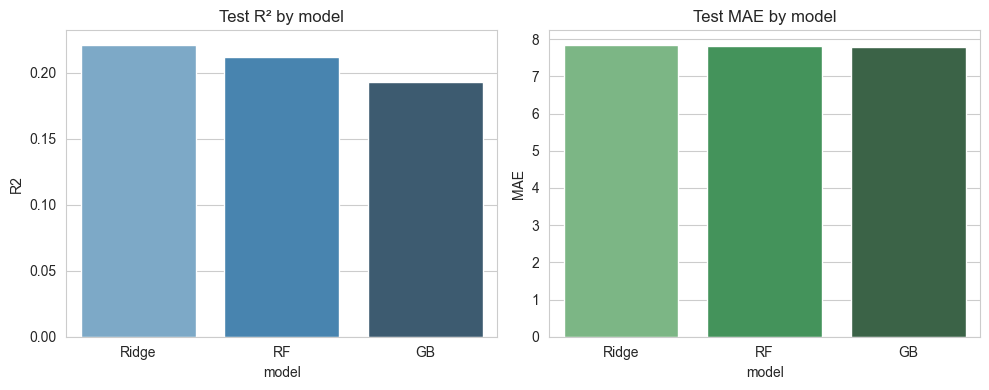

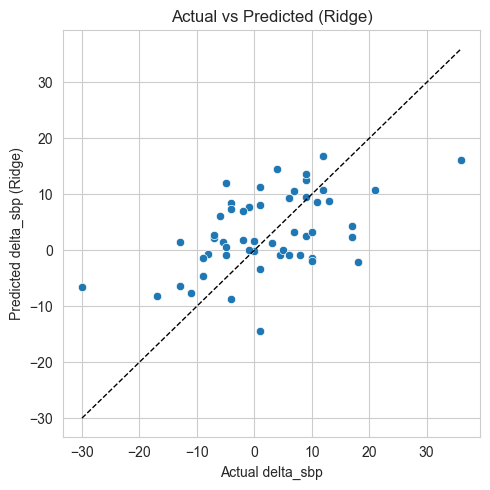

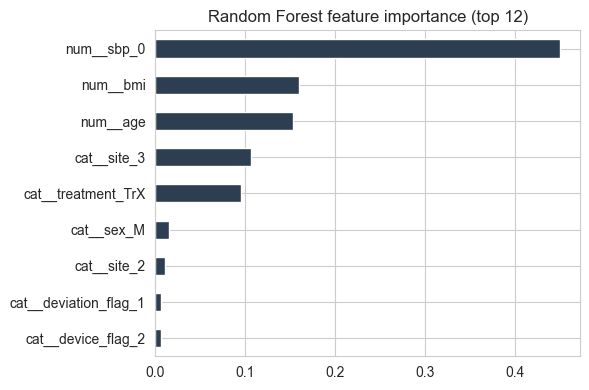

In [22]:
sns.set_style("whitegrid")

# Refit and store predictions
results = []
preds = {}
pipes = {}

for name, est in models.items():
    pipe = Pipeline([("prep", pre), ("model", est)])
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte)
    pipes[name] = pipe
    preds[name] = pred
    results.append({"model": name, "R2": r2_score(yte, pred), "MAE": mean_absolute_error(yte, pred)})

res_df = pd.DataFrame(results)
print(res_df)

# 1) Bar chart of R2 and MAE
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.barplot(data=res_df, x="model", y="R2", ax=axes[0], palette="Blues_d")
axes[0].set_title("Test R² by model")
sns.barplot(data=res_df, x="model", y="MAE", ax=axes[1], palette="Greens_d")
axes[1].set_title("Test MAE by model")
plt.tight_layout()
plt.show()

# 2) Actual vs predicted scatter for best R2 model
best = res_df.sort_values("R2", ascending=False).iloc[0]["model"]
fig, ax = plt.subplots(figsize=(5,5))
sns.scatterplot(x=yte, y=preds[best], ax=ax)
lims = [min(yte.min(), preds[best].min()), max(yte.max(), preds[best].max())]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlabel("Actual delta_sbp")
ax.set_ylabel(f"Predicted delta_sbp ({best})")
ax.set_title(f"Actual vs Predicted ({best})")
plt.tight_layout()
plt.show()

# 3) Feature importance for Random Forest 
rf_pipe = pipes["RF"]
feat_names = rf_pipe.named_steps["prep"].get_feature_names_out()
importances = rf_pipe.named_steps["model"].feature_importances_
imp = pd.Series(importances, index=feat_names).sort_values().tail(12)

fig, ax = plt.subplots(figsize=(6,4))
imp.plot(kind="barh", ax=ax, color="#2c3e50")
ax.set_title("Random Forest feature importance (top 12)")
plt.tight_layout()
plt.show()


---
> **Inference: ML Visualisations & Feature Importance**  
> 1. **R² and MAE bar charts:** Allow direct comparison of predictive accuracy across models. Higher R² and lower MAE indicate better fit. If RF or GB substantially outperform Ridge, it suggests non-linear interactions (e.g., age × BMI) are present in the data.  
> 2. **Actual vs Predicted scatter (best model):** Points clustering tightly around the 45° line indicate good calibration. Systematic over- or under-prediction at high/low delta_sbp values reveals where the model fails.  
> 3. **Random Forest feature importance:** Identifies which variables most strongly predict SBP reduction. If `sbp_0` dominates, regression-to-the-mean is driving most of the variance. If `treatment` ranks highly, it confirms TrX is a key independent predictor — consistent with the ANCOVA finding. This also helps prioritise which covariates to measure in a future Phase III trial.
---